In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

# make src/ importable
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
FEVER_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_DIR = os.path.join(FEVER_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
if FEVER_DIR not in sys.path:
    sys.path.insert(0, FEVER_DIR)

print(f"Repo root:  {REPO_ROOT}")
print(f"Fever dir:  {FEVER_DIR}")
print(f"Results:    {RESULTS_DIR}")

print("All imports successful")

Repo root:  /home/jovyan/lectures/raq-reproducibility-challenge
Fever dir:  /home/jovyan/lectures/raq-reproducibility-challenge/fever
Results:    /home/jovyan/lectures/raq-reproducibility-challenge/fever/results
All imports successful


In [5]:
dataset = load_dataset("copenlu/fever_gold_evidence")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/96.9M [00:00<?, ?B/s]

valid.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/228277 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/15935 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/16039 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 228277
    })
    validation: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 15935
    })
    test: Dataset({
        features: ['claim', 'label', 'evidence', 'id', 'verifiable', 'original_id'],
        num_rows: 16039
    })
})


In [6]:
# Inspection of one example from each split
print("=== TRAIN EXAMPLE ===")
print(dataset["train"][0])

print("\n=== VALIDATION EXAMPLE ===")
print(dataset["validation"][0])

print("\n=== TEST EXAMPLE ===")
print(dataset["test"][0])

=== TRAIN EXAMPLE ===
{'claim': 'The number of new cases of shingles per year extends from 1.2–3.4 per 1,000 among healthy individuals.', 'label': 'SUPPORTS', 'evidence': [['Shingles', '31', 'The number of new cases per year ranges from 1.2 -- 3.4 per 1,000 among healthy individuals to 3.9 -- 11.8 per 1,000 among those older than 65 years of age .']], 'id': '98faa551d5973b62591e0835bf898d84', 'verifiable': 'VERIFIABLE', 'original_id': 123397}

=== VALIDATION EXAMPLE ===
{'claim': 'Jackie (2016 film) was directed by Peter Jackson.', 'label': 'REFUTES', 'evidence': [['Jackie_-LRB-2016_film-RRB-', '0', 'Jackie is a 2016 biographical drama film directed by Pablo Larraín and written by Noah Oppenheim .']], 'id': 'e9a7305690bde211b7434ccd53b3a763', 'verifiable': 'VERIFIABLE', 'original_id': 70882}

=== TEST EXAMPLE ===
{'claim': 'Kareena Kapoor was a commercial failure.', 'label': 'NOT ENOUGH INFO', 'evidence': [['Kareena_Kapoor', '6', 'This initial success was followed by a series of commer

In [7]:
#Label structure
train_labels = dataset["train"]["label"]
unique_labels = set(train_labels)
print("Unique labels:", unique_labels)

# count distribution
from collections import Counter
label_counts = Counter(train_labels)
print("\nLabel distribution:")
for label, count in sorted(label_counts.items()):
    pct = count / len(train_labels) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")

Unique labels: {'NOT ENOUGH INFO', 'SUPPORTS', 'REFUTES'}

Label distribution:
  NOT ENOUGH INFO: 66,380 (29.1%)
  REFUTES: 47,096 (20.6%)
  SUPPORTS: 114,801 (50.3%)


In [14]:
import os

# build absolute path regardless of where notebook is running from
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
FEVER_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
RESULTS_DIR = os.path.join(FEVER_DIR, "results")

# create results dir if it doesn't exist
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Fever dir:    {FEVER_DIR}")
print(f"Results dir:  {RESULTS_DIR}")

Notebook dir: /home/jovyan/lectures/raq-reproducibility-challenge/fever/notebooks
Fever dir:    /home/jovyan/lectures/raq-reproducibility-challenge/fever
Results dir:  /home/jovyan/lectures/raq-reproducibility-challenge/fever/results


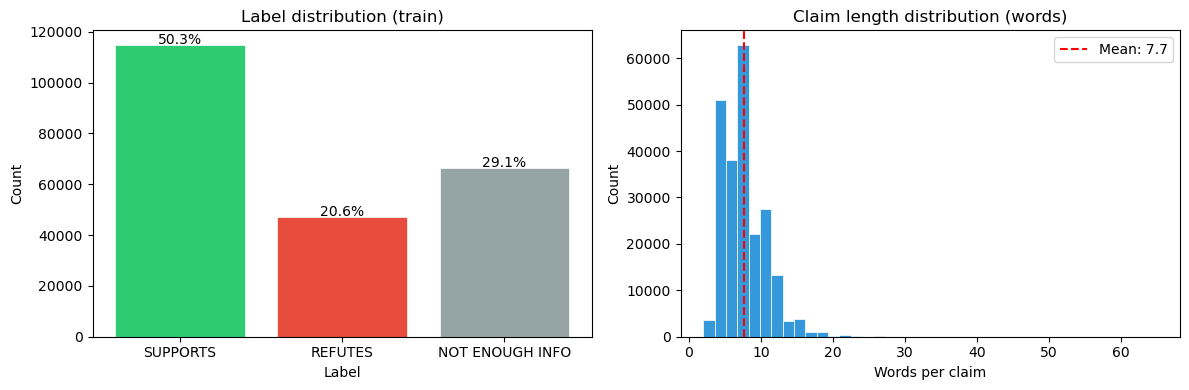

Mean claim length: 7.7 words
Max claim length:  65 words
Min claim length:  2 words


In [15]:
#Visualised label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
labels = ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]
counts = [label_counts[l] for l in labels]
colors = ["#2ecc71", "#e74c3c", "#95a5a6"]

axes[0].bar(labels, counts, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_title("Label distribution (train)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Label")
for i, (count, pct) in enumerate(zip(counts, [c/sum(counts)*100 for c in counts])):
    axes[0].text(i, count + 500, f"{pct:.1f}%", ha="center", fontsize=10)

# claim length distribution
claim_lengths = [len(c.split()) for c in dataset["train"]["claim"]]
axes[1].hist(claim_lengths, bins=40, color="#3498db", edgecolor="white", linewidth=0.5)
axes[1].set_title("Claim length distribution (words)")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Words per claim")
axes[1].axvline(np.mean(claim_lengths), color="red", 
                linestyle="--", label=f"Mean: {np.mean(claim_lengths):.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "label_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean claim length: {np.mean(claim_lengths):.1f} words")
print(f"Max claim length:  {np.max(claim_lengths)} words")
print(f"Min claim length:  {np.min(claim_lengths)} words")

In [16]:
# Inspect evidence structure and verifiable field
print("=== EVIDENCE STRUCTURE ===")
for i in range(3):
    example = dataset["train"][i]
    print(f"\nClaim: {example['claim']}")
    print(f"Label: {example['label']}")
    print(f"Verifiable: {example['verifiable']}")
    print(f"Evidence:")
    for ev in example["evidence"]:
        print(f"  Article: {ev[0]}, Sentence ID: {ev[1]}")
        print(f"  Text: {ev[2]}")

print("\n=== VERIFIABLE FIELD DISTRIBUTION ===")
verifiable_counts = Counter(dataset["train"]["verifiable"])
for k, v in verifiable_counts.items():
    print(f"  {k}: {v:,} ({v/len(dataset['train'])*100:.1f}%)")

print("\n=== SPLIT SIZES ===")
for split in ["train", "validation", "test"]:
    print(f"  {split}: {len(dataset[split]):,} examples")

print("\n=== NOTE ON DATASET SIZE VS PAPER ===")
print(f"  This dataset (copenlu/fever_gold_evidence): {len(dataset['train']):,} train examples")
print(f"  Original paper FEVER train set:             145,450 train examples")
print(f"  Difference: includes all evidence annotations, not just unique claims")

=== EVIDENCE STRUCTURE ===

Claim: The number of new cases of shingles per year extends from 1.2–3.4 per 1,000 among healthy individuals.
Label: SUPPORTS
Verifiable: VERIFIABLE
Evidence:
  Article: Shingles, Sentence ID: 31
  Text: The number of new cases per year ranges from 1.2 -- 3.4 per 1,000 among healthy individuals to 3.9 -- 11.8 per 1,000 among those older than 65 years of age .

Claim: Gabrielle Union was in a movie.
Label: SUPPORTS
Verifiable: VERIFIABLE
Evidence:
  Article: Gabrielle_Union, Sentence ID: 8
  Text: She co-starred in film The Birth of a Nation -LRB- 2016 -RRB- , and next appeared in Almost Christmas -LRB- 2016 -RRB- and Sleepless -LRB- 2017 -RRB- .

Claim: Eleveneleven was founded by a chef.
Label: REFUTES
Verifiable: VERIFIABLE
Evidence:
  Article: Eleveneleven, Sentence ID: 0
  Text: eleveneleven is a record label founded in 2010 by Mike Hamlin , Ellen DeGeneres and her production company , A Very Good Production , in association with longtime affiliate Warne

In [17]:
# Label mapping
LABEL2ID = {
    "SUPPORTS":        "0",
    "REFUTES":         "1", 
    "NOT ENOUGH INFO": "2"
}

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print("Label mapping for RAG (labels as single output tokens):")
for label, token in LABEL2ID.items():
    print(f"  '{label}' → token '{token}'")

print("\nThis is how FEVER becomes a generation task:")
print("  RAG generates '0', '1', or '2' as a single token")
print("  We map back to the string label for evaluation")
print("\nFor 2-way classification we only use SUPPORTS and REFUTES:")
LABEL2ID_2WAY = {
    "SUPPORTS": "0",
    "REFUTES":  "1"
}
print("  2-way mapping:", LABEL2ID_2WAY)

Label mapping for RAG (labels as single output tokens):
  'SUPPORTS' → token '0'
  'REFUTES' → token '1'
  'NOT ENOUGH INFO' → token '2'

This is how FEVER becomes a generation task:
  RAG generates '0', '1', or '2' as a single token
  We map back to the string label for evaluation

For 2-way classification we only use SUPPORTS and REFUTES:
  2-way mapping: {'SUPPORTS': '0', 'REFUTES': '1'}


In [18]:
# Save summary stats to results/
import json

summary = {
    "dataset": "copenlu/fever_gold_evidence",
    "splits": {
        split: len(dataset[split]) 
        for split in ["train", "validation", "test"]
    },
    "label_distribution_train": {
        label: {
            "count": count,
            "percentage": round(count / len(dataset["train"]) * 100, 1)
        }
        for label, count in label_counts.items()
    },
    "claim_length_stats": {
        "mean":   round(float(np.mean(claim_lengths)), 1),
        "median": round(float(np.median(claim_lengths)), 1),
        "min":    int(np.min(claim_lengths)),
        "max":    int(np.max(claim_lengths)),
        "std":    round(float(np.std(claim_lengths)), 1)
    },
    "label_mapping_3way": LABEL2ID,
    "label_mapping_2way": LABEL2ID_2WAY,
    "notes": [
        "Dataset has 228K train examples vs paper's 145K",
        "Difference due to multiple evidence annotations per claim",
        "Class imbalance: SUPPORTS 50.3%, NEI 29.1%, REFUTES 20.6%",
        "Evidence structure: [article_title, sentence_id, sentence_text]"
    ]
}

summary_path = os.path.join(RESULTS_DIR, "dataset_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to: {summary_path}")
print("\nContents:")
print(json.dumps(summary, indent=2))

Summary saved to: /home/jovyan/lectures/raq-reproducibility-challenge/fever/results/dataset_summary.json

Contents:
{
  "dataset": "copenlu/fever_gold_evidence",
  "splits": {
    "train": 228277,
    "validation": 15935,
    "test": 16039
  },
  "label_distribution_train": {
    "SUPPORTS": {
      "count": 114801,
      "percentage": 50.3
    },
    "REFUTES": {
      "count": 47096,
      "percentage": 20.6
    },
    "NOT ENOUGH INFO": {
      "count": 66380,
      "percentage": 29.1
    }
  },
  "claim_length_stats": {
    "mean": 7.7,
    "median": 7.0,
    "min": 2,
    "max": 65,
    "std": 3.0
  },
  "label_mapping_3way": {
    "SUPPORTS": "0",
    "REFUTES": "1",
    "NOT ENOUGH INFO": "2"
  },
  "label_mapping_2way": {
    "SUPPORTS": "0",
    "REFUTES": "1"
  },
  "notes": [
    "Dataset has 228K train examples vs paper's 145K",
    "Difference due to multiple evidence annotations per claim",
    "Class imbalance: SUPPORTS 50.3%, NEI 29.1%, REFUTES 20.6%",
    "Evidence str